# Lecture 02 Review:
- Data description
- Distribtions
- Probabilities

In [ ]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 33.4 MB/s eta 0:00:00


In [ ]:
### Load modules/functions ###
import os
import numpy as np
import xarray as xr

from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import linalg
from scipy import stats
import matplotlib.patches as mpatches

from numpy.linalg import inv
from IPython.display import Image
from matplotlib import image


%config InlineBackend.figure_format = 'retina'
%matplotlib inline

We are are going to use NOAA ERSSTv5
- Extended Reconstructed Sea Surface Temperature Version 5
- Monthly data going back to January 1854
- https://psl.noaa.gov/data/gridded/data.noaa.ersst.v5.html

In [ ]:
# where you want the SST data file to go
dest = './ERSSTv5.sst.mnmean.nc'
url  = 'https://downloads.psl.noaa.gov/Datasets/noaa.ersst.v5/sst.mnmean.nc'

# large data, so we check if it has been downloaded
if os.path.exists(dest):
    !curl -L -R -z "{dest}" -o "{dest}" --fail "{url}"  ## only download if the remote file is newer...
else:
    !curl -L -R -o "{dest}" --fail "{url}"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0   497    0     0    0     0      0      0 --:--:--  0:01:00 --:--:--     0
curl: (22) The requested URL returned error: 504


In [ ]:
ds_ersstv5 = xr.open_dataset(dest)
### Check data
ds_ersstv5

/home/clee/anaconda3/envs/py3.9/lib/python3.9/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'cfgrib' loading failed:
libffi.so.7: cannot open shared object file: No such file or directory
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 2070, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1854-01-01 1854-02-01 ... 2026-06-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 ...
    sst        (time, lat, lon) float32 ...
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2026-07-03

In [ ]:
## I like to name the variables using conventional name
ds_ersstv5 = ds_ersstv5.rename({'lat': 'latitude', 'lon': 'longitude'})
ds_ersstv5.attrs['short_name'] = 'ERSSTv5'
ds_ersstv5

<xarray.Dataset>
Dimensions:    (latitude: 89, longitude: 180, time: 2070, nbnds: 2)
Coordinates:
  * latitude   (latitude) float32 88.0 86.0 84.0 82.0 ... -84.0 -86.0 -88.0
  * longitude  (longitude) float32 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1854-01-01 1854-02-01 ... 2026-06-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 ...
    sst        (time, latitude, longitude) float32 ...
Attributes: (12/38)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2026-07-03
    short_name:                ERSSTv5

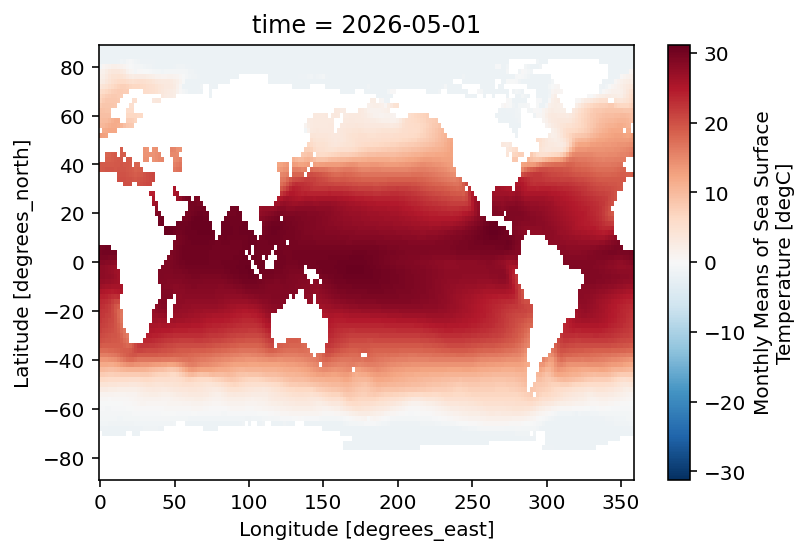

In [ ]:
### 2D map of SST for May
sst = ds_ersstv5['sst']
sst.isel(time=-2).plot()
plt.savefig('May_SST.png',dpi=200)
plt.show()

- Q: how warm it is? Look at Anomaly

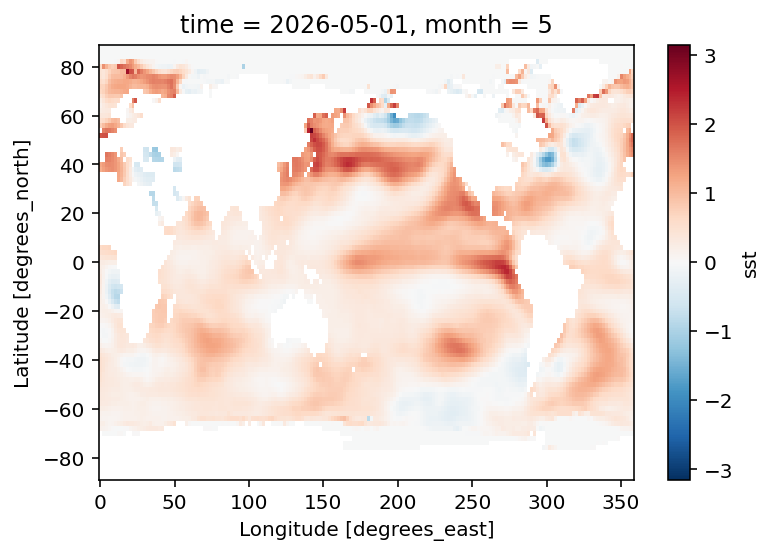

In [ ]:
### NOAA's definition of climatology -- past 30 years
monthly_mean_sst = sst.sel(time=slice('1991', '2020')).groupby('time.month').mean('time')
ssta = sst.groupby('time.month') - monthly_mean_sst
ssta.isel(time=-2).plot()

- Q: What kind feature do you see?
- Q: How strong is this year's ENSO? How does it compared to 1997 ENSO (in May)?



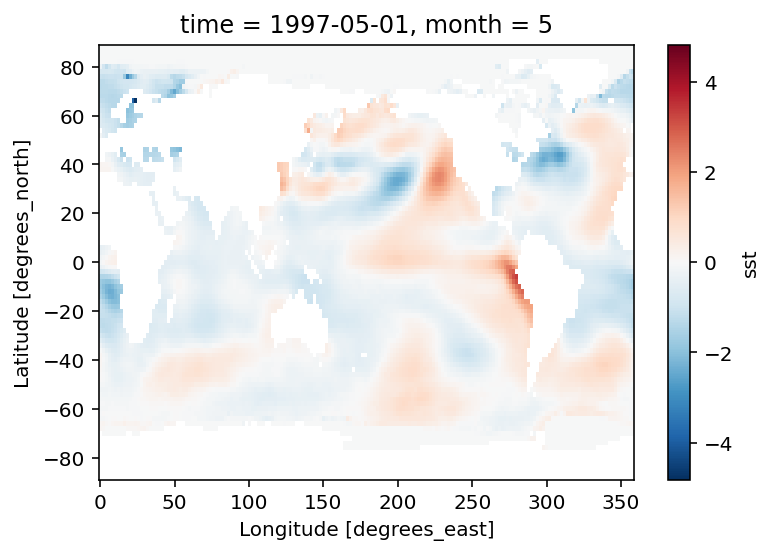

In [ ]:
ssta.sel(time='1997-05-01').plot()

- A better way to answer the above quesiton, let's check Niño 3.4 index:  Nino34 tracks sea surface temperature anomalies in a specific central-to-eastern equatorial Pacific region (5°N–5°S, 120°W–170°W).

- link on Nino34

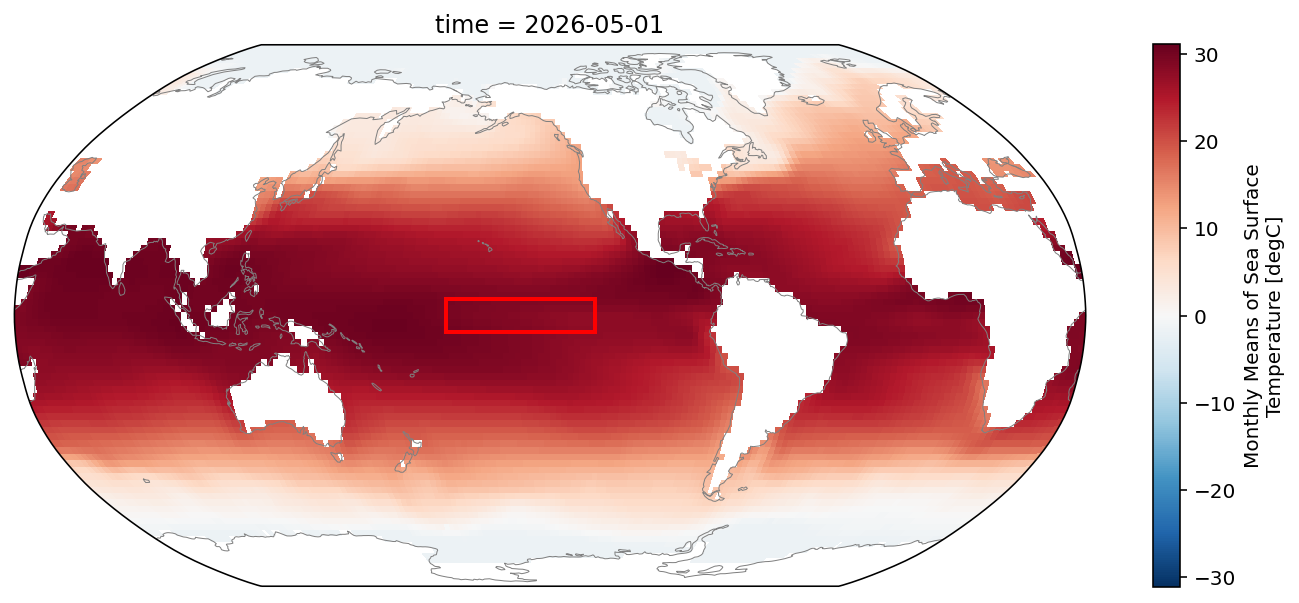

In [ ]:
### make a nicer global map with right projections

map_projection = ccrs.Robinson(central_longitude=225)

g = sst.isel(time=-2).plot(transform=ccrs.PlateCarree(),
                        subplot_kws={'projection': map_projection},
                        aspect=2.4,
                        size=5,
)
g.axes.coastlines(resolution="110m", linewidth=0.5, color='gray')

ax = plt.gca()  # grabs the axes xarray just created


# Niño 3.4 box: 5N-5S, 170W-120W  (i.e., 190E-240E)
lon_min, lon_max = -170, -120  # in -180 to 180 convention
lat_min, lat_max = -5, 5

# add patches to it
box = mpatches.Rectangle(
    (lon_min, lat_min),
    lon_max - lon_min,
    lat_max - lat_min,
    linewidth=2,
    edgecolor='red',
    facecolor='none',
    transform=ccrs.PlateCarree(),
    zorder=5
)
ax.add_patch(box)

plt.savefig('May_SST.png',dpi=200)
plt.show()

Before we do anything, let's cut data from 1951, and focus on only 30 $^\circ$S to 30 $^\circ$N

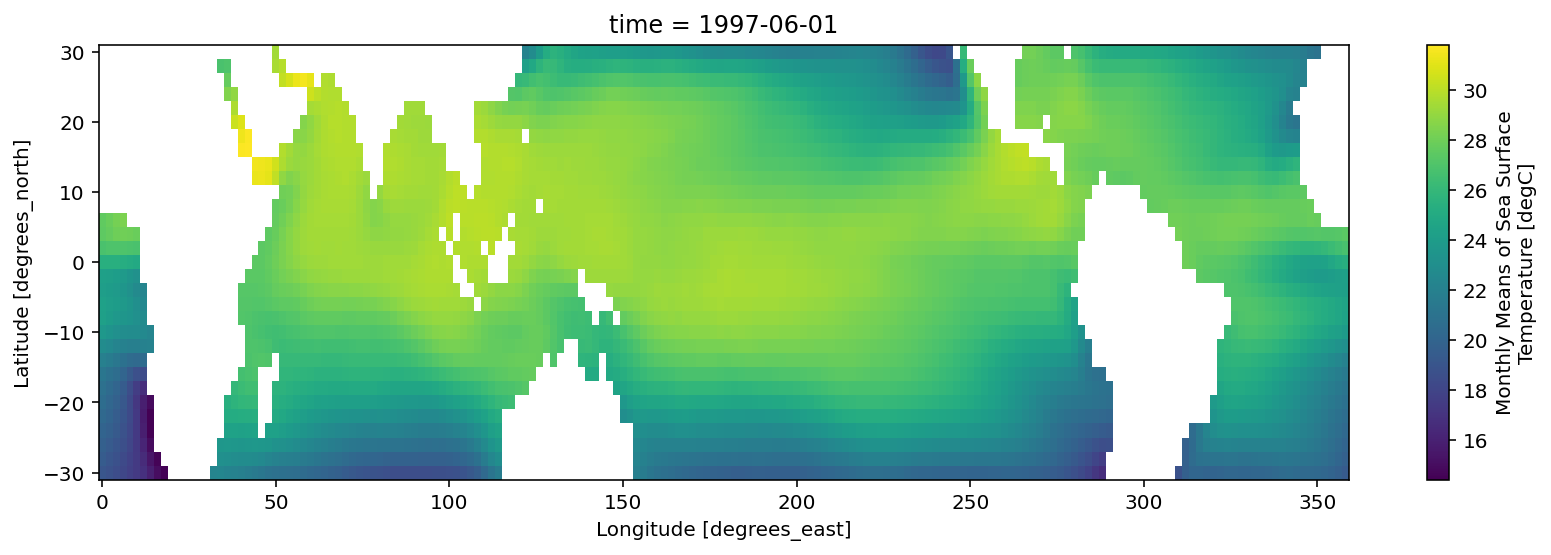

In [ ]:
sst = ds_ersstv5['sst'].sel(latitude=slice(30, -30), time=slice('1951', None))
#sst = sst.sel(time=sst.time.dt.month == 10) ## if wants to select specific months

# Plot a value
sst_1997 = sst.sel(time='1997-06-01')
sst_1997.plot(figsize=(14,4))
plt.show()

Now you need to write a fucntion to calcualte Niño 3.4

In [ ]:
def n34_average(x):
    """
    Calculate x (temperature) over Niño 3.4 region"
    Note that grid cells near the equator represent more actual surface area than cells near the poles
    (since longitude lines converge toward the poles),
    so a simple unweighted mean would bias the average toward high latitudes. Weighting by cos(latitude) corrects for this.
    """

    x = x.sortby("latitude")
    weights = np.cos(np.deg2rad(x.latitude))
    y = x.sel(longitude=slice(190, 240)).sel(latitude=slice(-5, 5)).weighted(weights).mean(['longitude', 'latitude'])
    y.attrs = x.attrs.copy()
    return y

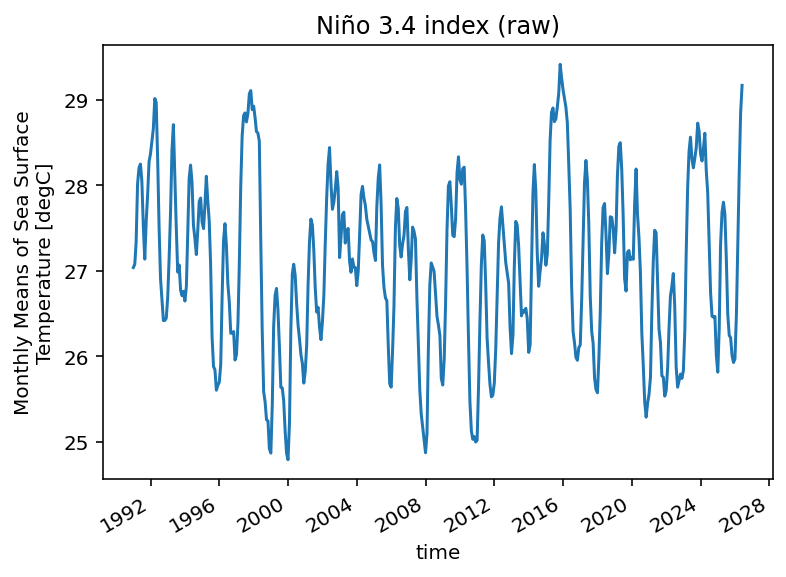

In [ ]:
import pandas as pd
n34 = n34_average(sst)
n34.sel(time=slice('1991', '2026')).plot()
ax = plt.gca()


# grab the value at May 2026
arget_date = '2026-05'
val = n34.sel(time=target_date)

#x.plot(pd.Timestamp('2026-05-15'), val.values,
#       marker='o', color='red', markersize=8, zorder=5)
#x.annotate('May 2026',
#           xy=(pd.Timestamp('2026-05-15'), val.values),
#           xytext=(10, 10), textcoords='offset points',
#           fontsize=9, color='red')
plt.title('Niño 3.4 index (raw)')
plt.savefig('n34.png',dpi=200)

Save the n34 for future use

In [ ]:
df = n34.to_dataframe(name="nino34").reset_index()
df.to_csv("n34_1991_2026.csv", index=False)

Now we have organized the data from a 3D SST field (longitude, latitude, time) into 1D time series data. Let's go back to answer how warm this year's tropical Pacific is

We start by 'describing' the data

(array([ 0.,  0.,  0.,  6., 10.,  9., 20., 12., 22., 24., 24., 29., 37.,
        41., 36., 23., 27.,  9., 11., 12.,  6.,  2.,  0.]),
 array([24.  , 24.25, 24.5 , 24.75, 25.  , 25.25, 25.5 , 25.75, 26.  ,
        26.25, 26.5 , 26.75, 27.  , 27.25, 27.5 , 27.75, 28.  , 28.25,
        28.5 , 28.75, 29.  , 29.25, 29.5 , 29.75]),
 <BarContainer object of 23 artists>)

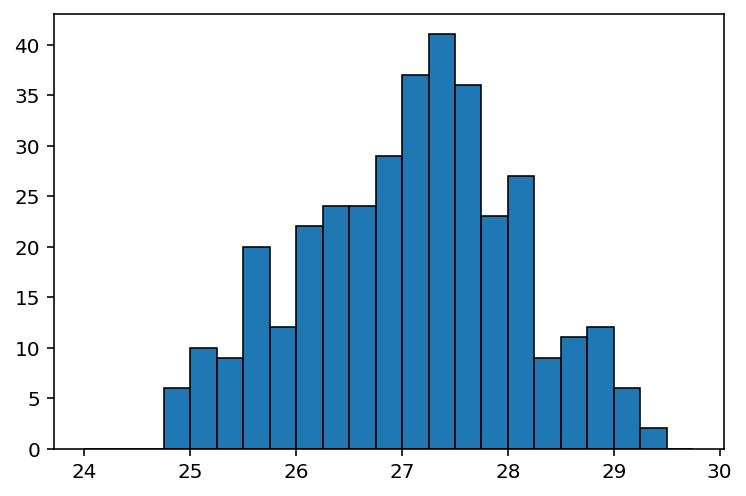

In [ ]:
data = n34.sel(time=slice('1991', '2020'))

plt.hist(data,
         bins=np.arange(24, 30, 0.25),
         edgecolor='black',
         linewidth=0.8)



### Sample Mean
$$\hat{\mu} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

In [ ]:
mean_val = np.mean(data).values
print (mean_val)

27.083048


### Sample Standard Deviation

$$\hat{\sigma} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (x_i - \hat{\mu})^2}$$

In [ ]:
std_val = np.std(data).values
print (std_val)

1.0027070045471191


### Sample Skewness
$$\hat{\gamma} = \frac{\frac{1}{n}\sum_{i=1}^{n} (x_i - \hat{\mu})^3}{\hat{\sigma}^3}$$

In [ ]:
skew_val = stats.skew(data.values.flatten())
print (skew_val)

-0.12100280742677219


### Sample Kurtosis
$$\hat{k} = \frac{\frac{1}{n}\sum_{i=1}^{n} (x_i - \hat{\mu})^4}{\hat{\sigma}^4}$$

In [ ]:
kurt_val = stats.kurtosis(data.values.flatten())  # excess kurtosis (normal = 0) by default
print(kurt_val)

-0.5124862912210819


### Quantiles


In [ ]:
median_val = np.median(data)
print ('median:', median_val)
p5, p95 = np.percentile(data, [5, 95])
print ('5th percentile:',p5)
print('95th percentile:',p95)

median: 27.143358
5th percentile: 25.326422595977782
95th percentile: 28.78778667449951


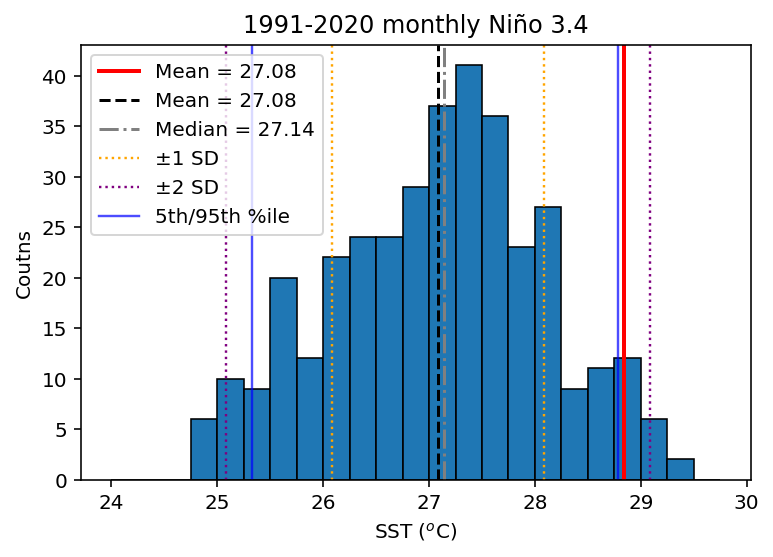

In [ ]:
plt.hist(data,
         bins=np.arange(24, 30, 0.25),
         edgecolor='black',
         linewidth=0.8)
plt.axvline(val, color='red', linestyle='-', linewidth=2, label=f'Mean = {mean_val:.2f}')


plt.axvline(mean_val, color='black', linestyle='--', linewidth=1.5, label=f'Mean = {mean_val:.2f}')
plt.axvline(median_val, color='gray', linestyle='-.', linewidth=1.5, label=f'Median = {median_val:.2f}')

# ±1 and ±2 standard deviations
plt.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.2, label='±1 SD')
plt.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.2)
plt.axvline(mean_val + 2*std_val, color='purple', linestyle=':', linewidth=1.2, label='±2 SD')
plt.axvline(mean_val - 2*std_val, color='purple', linestyle=':', linewidth=1.2)

# 5th and 95th percentiles
plt.axvline(p5, color='blue', linestyle='-', linewidth=1.2, alpha=0.7, label='5th/95th %ile')
plt.axvline(p95, color='blue', linestyle='-', linewidth=1.2, alpha=0.7)

plt.legend()
plt.xlabel('SST ($^o$C)')
plt.ylabel('Coutns')
plt.title('1991-2020 monthly Niño 3.4')
plt.savefig('N34_hist.png',dpi=200)

Now, what do you see?

### Distributions and probabilities

### Normal Distribuiton
$$p(x) = \frac{1}{\hat{\sigma}\sqrt{2\pi}} \exp\left(-\frac{(x-\hat{\mu})^2}{2\hat{\sigma}^2}\right)$$

In [ ]:
# Load data
df = pd.read_csv('n34_1991_2026.csv')
x = df['nino34'].dropna().values

# Fit normal distribution (returns MLE estimates of mu and sigma)
mu, sigma = stats.norm.fit(x)
print(f"n = {len(x)}")
print(f"mu (mean) = {mu:.4f}")
print(f"sigma (std) = {sigma:.4f}")


n = 906
mu (mean) = 26.9237
sigma (std) = 0.9822


- let's see how good the fit is using historgram

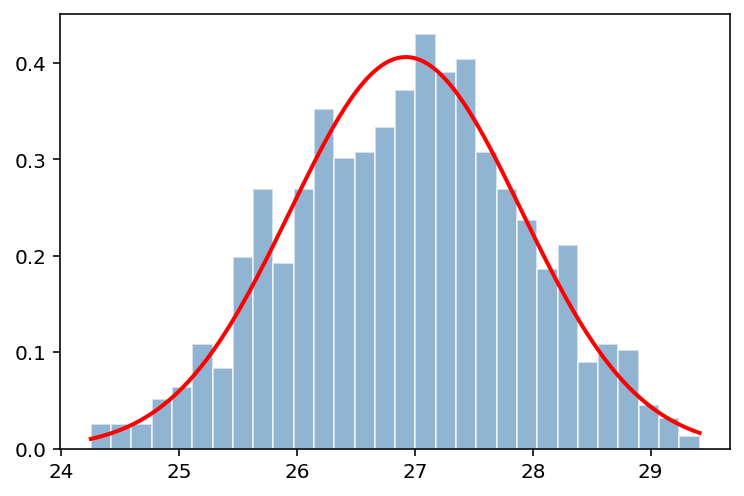

In [ ]:
plt.hist(x, bins=30, density=True, alpha=0.6, color='steelblue', edgecolor='white')
xs = np.linspace(x.min(), x.max(), 200)
plt.plot(xs, stats.norm.pdf(xs, mu, sigma), 'r-', lw=2,
        label=f'Normal fit\n$\\mu$={mu:.2f}, $\\sigma$={sigma:.2f}')
plt.show()

- let's try QQ plot

Text(0.5, 1.0, 'Q-Q Plot vs Normal Distribution')

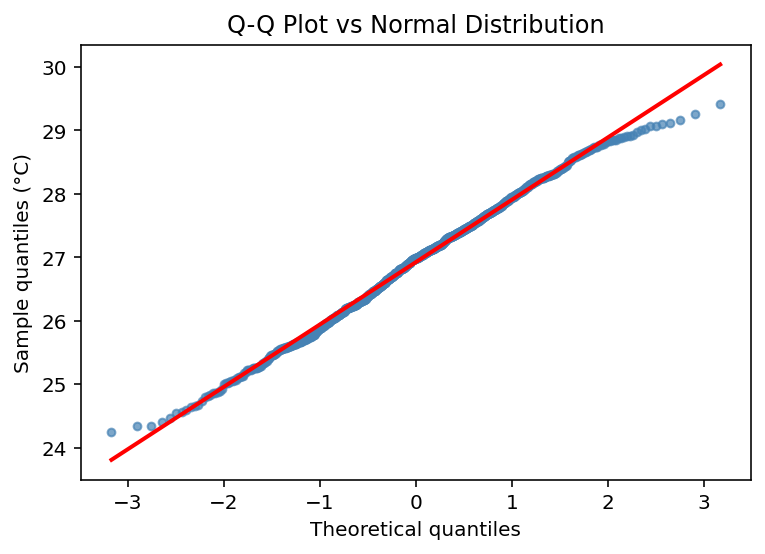

In [ ]:
(osm, osr), (slope, intercept, r) = stats.probplot(x, dist='norm', plot=None)
plt.scatter(osm, osr, s=15, color='steelblue', alpha=0.7, label='Data')
plt.plot(osm, slope * osm + intercept, 'r-', lw=2, label=f'Fit line ($r^2$={r**2:.3f})')
plt.xlabel('Theoretical quantiles')
plt.ylabel('Sample quantiles (°C)')
plt.title('Q-Q Plot vs Normal Distribution')

### Gamma
$$p(x) = \frac{1}{\Gamma(k)\,\theta^{k}} x^{k-1} e^{-x/\theta}, \quad x > 0$$

In [ ]:
import urllib.request
### I ordered NYC data in August"
url = "https://www.ncei.noaa.gov/orders/cdo/4371519.csv"
urllib.request.urlretrieve(url, "NYC_data.csv")

('NYC_data.csv', <http.client.HTTPMessage at 0x7f397130ffd0>)

In [ ]:
df = pd.read_csv('NYC_data.csv')

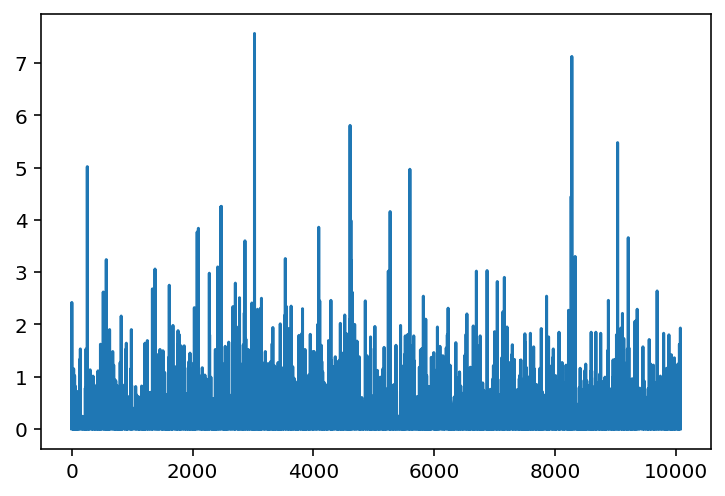

In [ ]:
plt.plot(df.PRCP)

In [ ]:
# --- Load and clean data ---
df = pd.read_csv('NYC_data.csv')
df['DATE'] = pd.to_datetime(df['DATE'])
df['PRCP'] = pd.to_numeric(df['PRCP'], errors='coerce')
df = df.dropna(subset=['PRCP'])

print(f"Date range: {df['DATE'].min().date()} to {df['DATE'].max().date()}")
print(f"n days = {len(df)}")

# --- Isolate wet days (gamma is undefined at 0, and dry days dominate) ---
wet = df.loc[df['PRCP'] > 0, 'PRCP'].values
frac_wet = len(wet) / len(df)
print(f"Wet days: {len(wet)} ({frac_wet*100:.1f}% of days)")

# --- Fit Gamma distribution (location fixed at 0, standard for precip) ---
shape, loc, scale = stats.gamma.fit(wet, floc=0)
print(f"Gamma fit: shape (k) = {shape:.4f}, scale (theta) = {scale:.4f}")
print(f"Implied mean = {shape*scale:.4f}, variance = {shape*scale**2:.4f}")




Date range: 1999-01-01 to 2026-08-04
n days = 10078
Wet days: 3481 (34.5% of days)
Gamma fit: shape (k) = 0.6491, scale (theta) = 0.6160
Implied mean = 0.3998, variance = 0.2463


Text(0.5, 1.0, 'Daily Precipitation, NYC Central Park (Full Record)')

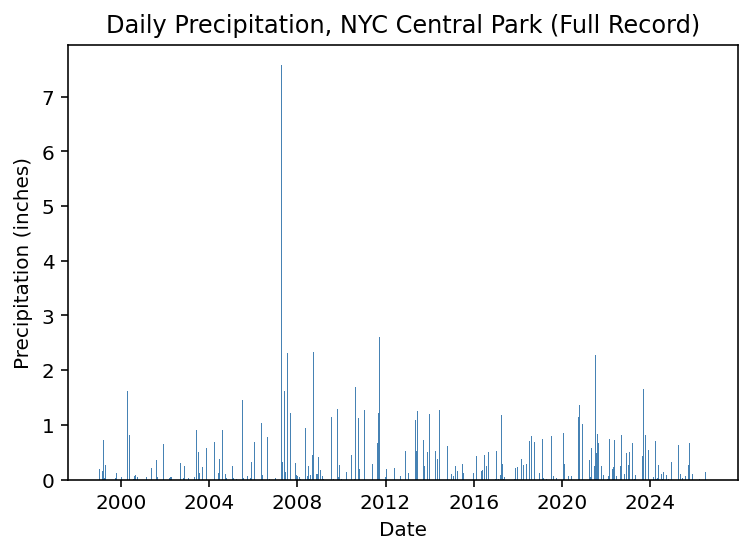

In [ ]:
plt.bar(df['DATE'], df['PRCP'], width=1.0, color='steelblue')
plt.xlabel('Date')
plt.ylabel('Precipitation (inches)')
plt.title('Daily Precipitation, NYC Central Park (Full Record)')

Text(0.5, 1.0, 'Wet-day Precipitation with fitted Gamma\n(bin width = 0.1 in, n=3481)')

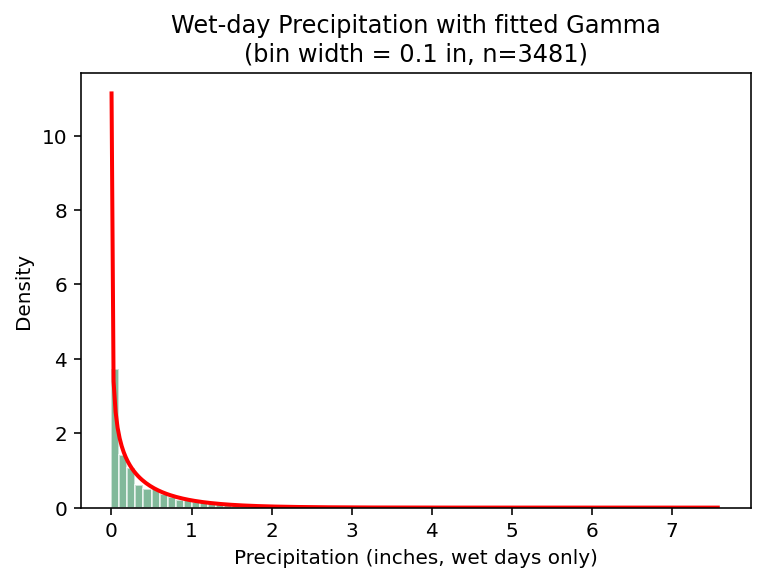

In [ ]:
# --- Plot 2: Histogram (0.1 in bins) + Gamma fit, and Q-Q plot ---
bin_width = 0.1
bins = np.arange(0, wet.max() + bin_width, bin_width)
plt.hist(wet, bins=bins, density=True, alpha=0.6, color='seagreen', edgecolor='white')
xs = np.linspace(0.001, wet.max(), 300)
plt.plot(xs, stats.gamma.pdf(xs, shape, loc, scale), 'r-', lw=2,
        label=f'Gamma fit\nk={shape:.2f}, $\\theta$={scale:.2f}')
plt.xlabel('Precipitation (inches, wet days only)')
plt.ylabel('Density')
plt.title(f'Wet-day Precipitation with fitted Gamma\n(bin width = 0.1 in, n={len(wet)})')

Text(0.5, 1.0, 'Q-Q Plot vs Gamma Distribution')

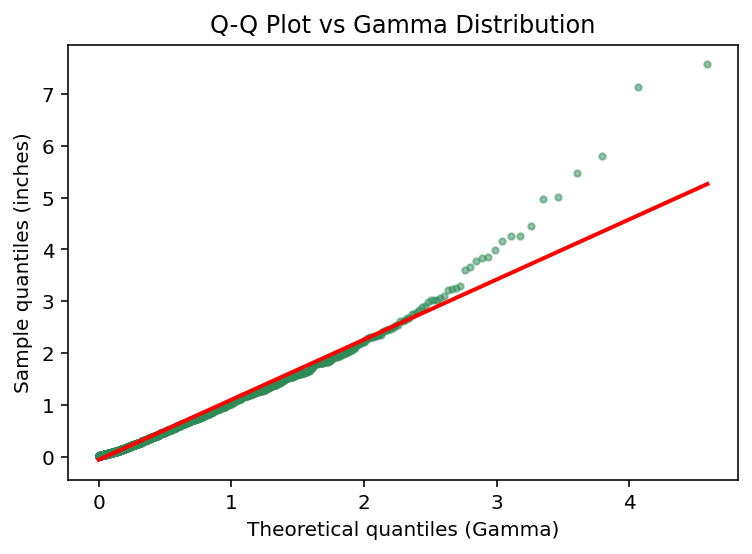

In [ ]:
(osm, osr), (slope, intercept, r) = stats.probplot(
    wet, dist=stats.gamma, sparams=(shape, loc, scale), plot=None
)
plt.scatter(osm, osr, s=10, color='seagreen', alpha=0.5, label='Data')
plt.plot(osm, slope*osm + intercept, 'r-', lw=2, label=f'Fit line ($r^2$={r**2:.3f})')
plt.xlabel('Theoretical quantiles (Gamma)')
plt.ylabel('Sample quantiles (inches)')
plt.title('Q-Q Plot vs Gamma Distribution')

In [ ]:
# --- Aggregate to monthly total precipitation ---
monthly = df.set_index('DATE')['PRCP'].resample('MS').sum()
monthly = monthly[monthly.index < monthly.index.max()]  # drop possibly incomplete last month

print(f"n months = {len(monthly)}")
print(f"Monthly mean precip = {monthly.mean():.4f} in")
print(f"Monthly std = {monthly.std():.4f} in")

# --- Fit Gamma distribution ---
shape, loc, scale = stats.gamma.fit(monthly.values, floc=0)
print(f"Gamma fit: shape (k) = {shape:.4f}, scale (theta) = {scale:.4f}")
print(f"Implied mean = {shape*scale:.4f}, variance = {shape*scale**2:.4f}")



n months = 331
Monthly mean precip = 4.1988 in
Monthly std = 2.4353 in
Gamma fit: shape (k) = 3.0109, scale (theta) = 1.3945
Implied mean = 4.1988, variance = 5.8553


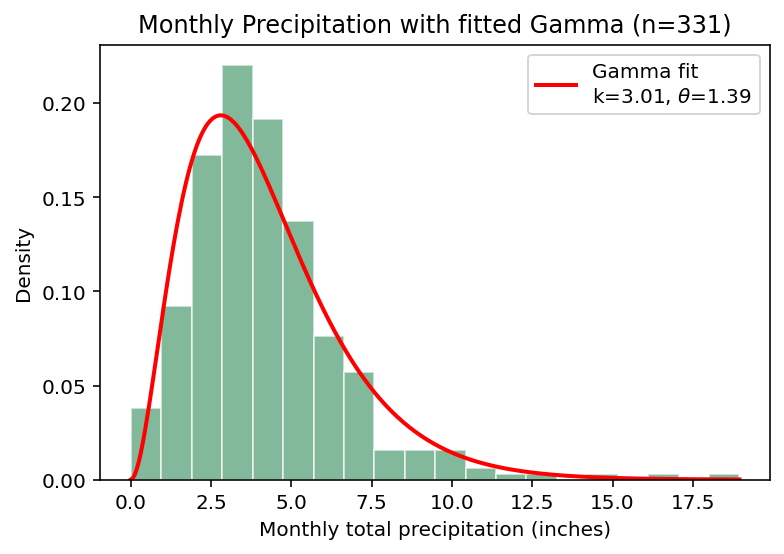

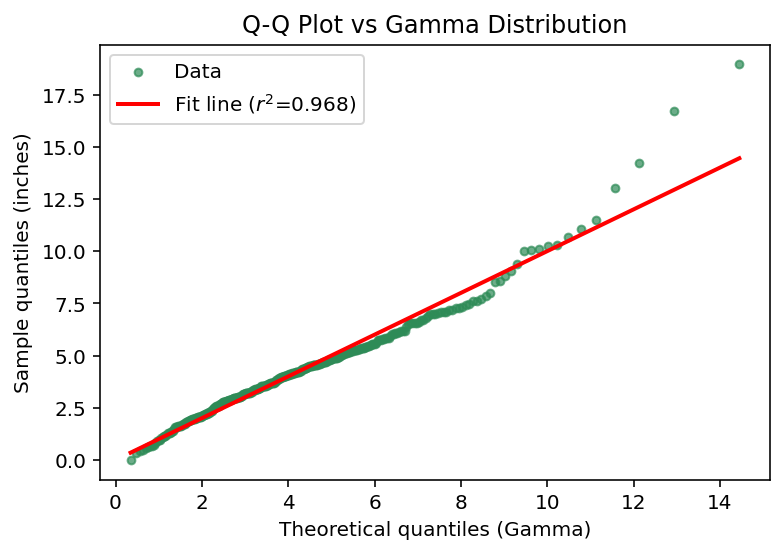

In [ ]:
plt.figure()
plt.hist(monthly.values, bins=20, density=True, alpha=0.6, color='seagreen', edgecolor='white')
xs = np.linspace(0.001, monthly.max(), 300)
plt.plot(xs, stats.gamma.pdf(xs, shape, loc, scale), 'r-', lw=2,
        label=f'Gamma fit\nk={shape:.2f}, $\\theta$={scale:.2f}')
plt.xlabel('Monthly total precipitation (inches)')
plt.ylabel('Density')
plt.title(f'Monthly Precipitation with fitted Gamma (n={len(monthly)})')
plt.legend()

plt.figure()
(osm, osr), (slope, intercept, r) = stats.probplot(
    monthly.values, dist=stats.gamma, sparams=(shape, loc, scale), plot=None
)
plt.scatter(osm, osr, s=15, color='seagreen', alpha=0.7, label='Data')
plt.plot(osm, slope*osm + intercept, 'r-', lw=2, label=f'Fit line ($r^2$={r**2:.3f})')
plt.xlabel('Theoretical quantiles (Gamma)')
plt.ylabel('Sample quantiles (inches)')
plt.title('Q-Q Plot vs Gamma Distribution')
plt.legend()



